# Árboles

## EDA Companies

In [130]:
# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparación de los datos
from feature_engine.outliers import Winsorizer # remoción de outliers
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
# modelos
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score,
                            confusion_matrix,classification_report)
from sklearn.tree import plot_tree
from sklearn.naive_bayes import MultinomialNB

In [131]:
df = pd.read_csv('1000_Companies.csv') # cargamos dataset

In [132]:
df.head() # Vemos una primera observacion del dataset

,RyD_Spend,Administration,MarketingSpend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [133]:
df.info() # Tipo de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [134]:
df.describe() 

,RyD_Spend,Administration,MarketingSpend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122963.897612,226205.058419,119546.164656
std,46537.567891,12613.927535,91578.393542,42888.633848
min,0.000000,51283.140000,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,321652.140000,471784.100000,476485.430000


In [135]:
print(df.isna().sum()[df.isna().sum() > 0]) # Vemos la cantidad de nulos. No tenemos.

Series([], dtype: int64)


In [136]:
df.State.unique() # vemos los valores unicos de los estados

array(['New York', 'California', 'Florida'], dtype=object)

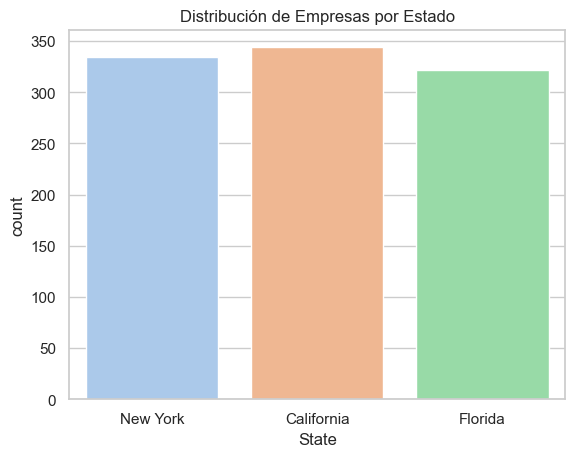

In [137]:
df['State'].value_counts()
sns.countplot(data=df, x='State', hue='State')
plt.title('Distribución de Empresas por Estado')
plt.show()


La cantidad de datos para estado es pareja.

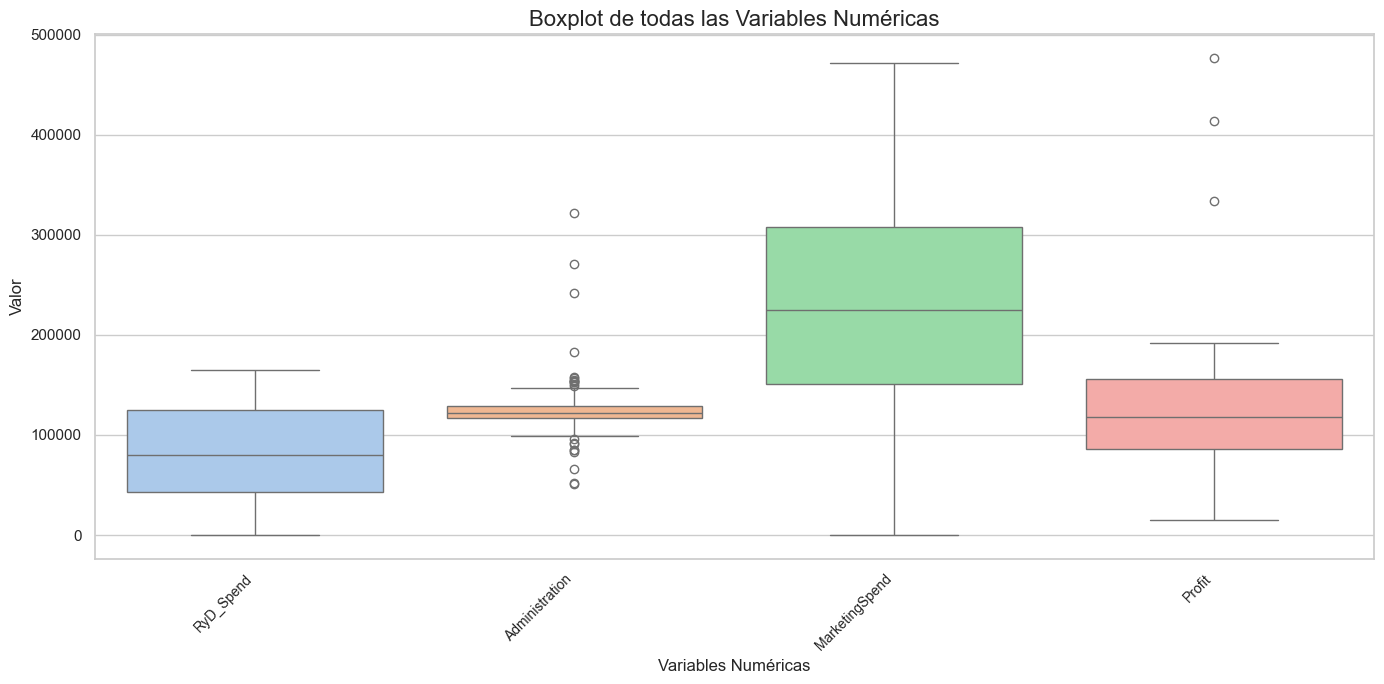

In [138]:
numerical_cols = df.select_dtypes(include=np.number).columns
df_numerical = df[numerical_cols]


plt.figure(figsize=(14, 7)) # Ajusta el tamaño según la cantidad de columnas
sns.boxplot(data=df_numerical)
plt.title('Boxplot de todas las Variables Numéricas', fontsize=16)
plt.ylabel('Valor', fontsize=12)
plt.xlabel('Variables Numéricas', fontsize=12)

# Rotar las etiquetas del eje X si hay muchas columnas para evitar superposiciones
plt.xticks(rotation=45, ha='right', fontsize=10) # 'ha' es para la alineación horizontal
plt.tight_layout()
plt.show()

Se puede observar que para las variables de administration y profit se presentan valores atipicos. Se mantienen los valores en profit al ser la variable target

In [139]:
df_copy = df.copy()

Se visualiza en el siguiente gráfico que las distribuciones de la variable Administration son muy similares para cada estado, por lo que se decide eliminar los outliers de manera general. Se puede ver el resultado en el segundo gráfico.

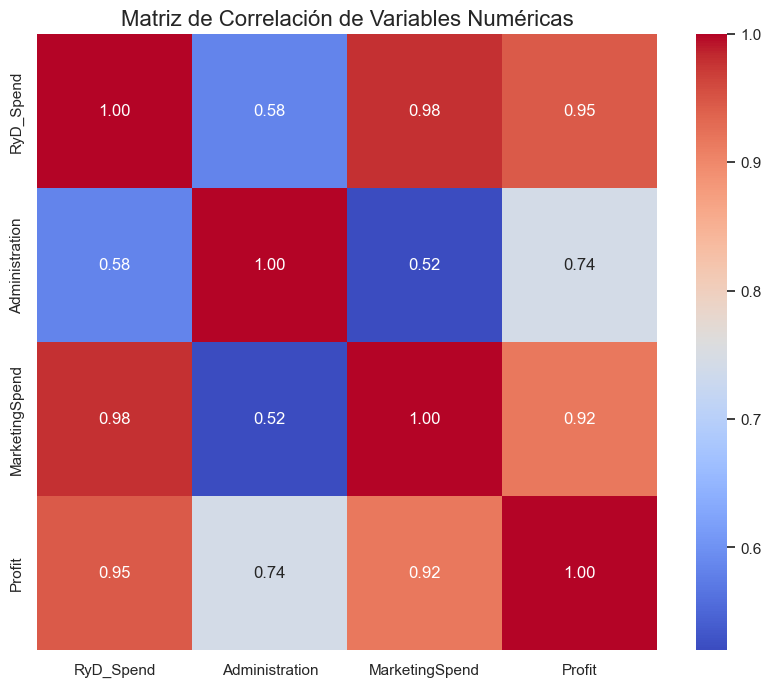

In [140]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

Se observa una alta positiva fuerte entre la variable objetivo y las variables Administration y MarketingSpend.

In [141]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


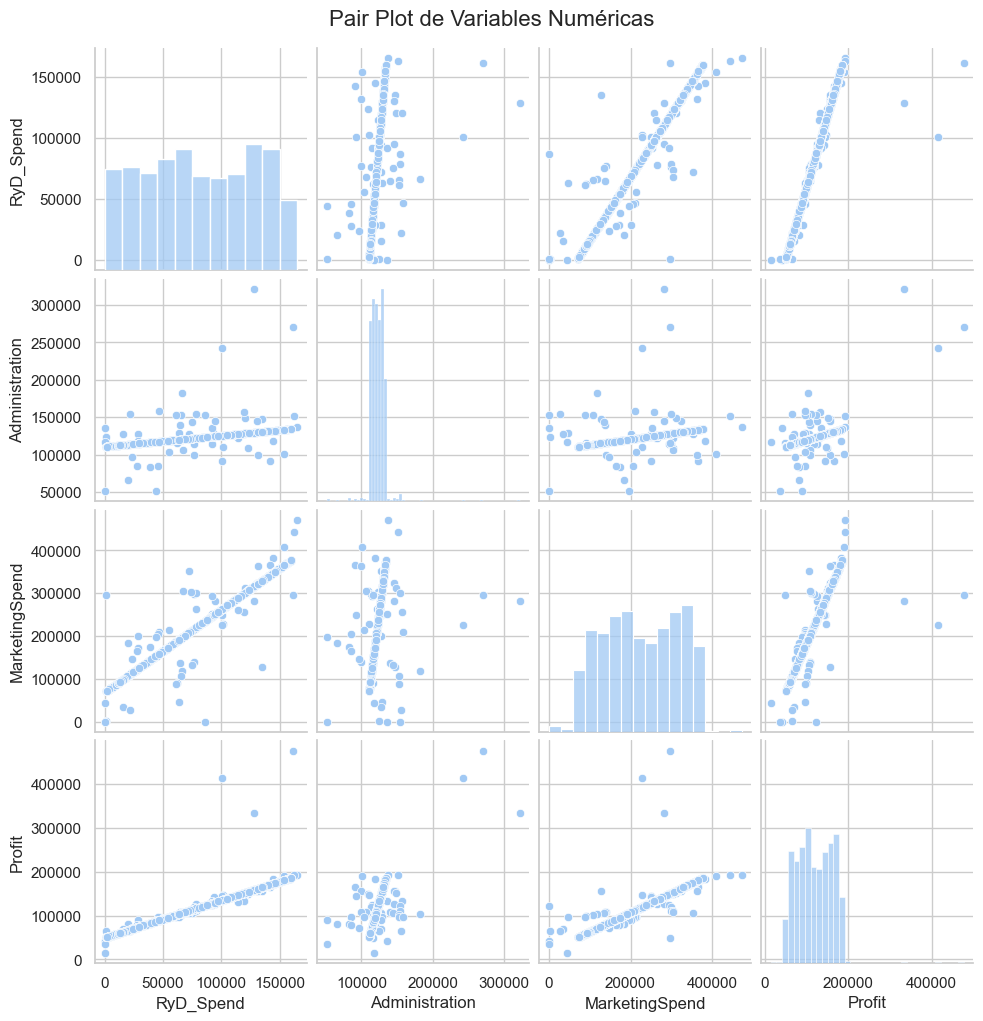

In [142]:
sns.pairplot(df_numerical)
plt.suptitle('Pair Plot de Variables Numéricas', y=1.02, fontsize=16) # Ajusta el título
plt.show()

Se realiza un onehoyencoder sobre la columna de State.

In [143]:
enc = OneHotEncoder(sparse_output=False)
estados = enc.fit_transform(df_copy[['State']])
estados_df = pd.DataFrame(estados, columns=enc.get_feature_names_out(['State']), index=df_copy.index)
df_final = pd.concat([estados_df, df_copy], axis=1).drop(columns='State',axis=1)


In [144]:
df_final.sample(5)

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend,Profit
707,1.0,0.0,0.0,83476.00,122785.2115,229846.2091,120345.7256
430,0.0,1.0,0.0,77031.00,121833.3846,217410.5640,114839.8177
233,1.0,0.0,0.0,86530.00,123236.2402,235738.9105,122954.7315
36,0.0,1.0,0.0,28663.76,127056.2100,201126.8200,90708.1900
393,0.0,0.0,1.0,127190.00,129241.0942,314192.4915,157690.2186


## SPLIT Companies

In [145]:
X = df_final.drop(columns='Profit', axis=1)
y = df_final['Profit']

In [146]:
# Obtengo datos de entrenamiento y de testeo
X_train80, X_test20, y_train80, y_test20  = train_test_split(X, y, test_size=0.2,
                            random_state=13, shuffle=True)

# Obtengo datos de entrenamiento y de testeo
X_train70, X_test30, y_train70, y_test30  = train_test_split(X, y, test_size=0.3,
                            random_state=12, shuffle=True)

In [147]:
X_train80.head() # Se observa un split 

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend
133,0.0,1.0,0.0,102790.0,125637.5910,267112.62490
233,1.0,0.0,0.0,86530.0,123236.2402,235738.91050
643,0.0,0.0,1.0,4187.0,111075.4508,76857.86711
497,1.0,0.0,0.0,105465.0,126032.6472,272274.04470
281,1.0,0.0,0.0,70529.0,120873.1396,204864.93730


Tratamiento de outliers para ambos splits

In [148]:
cols = ['Administration']
winsor = Winsorizer(capping_method='iqr', tail='both',fold=1.5)

# primer split 80-20
X_train80[cols] = winsor.fit_transform(X_train80[cols])
X_test20[cols] = winsor.transform(X_test20[cols])
# segundo split 70-30
X_train70[cols] = winsor.fit_transform(X_train70[cols])
X_test20[cols] = winsor.transform(X_test30[cols])

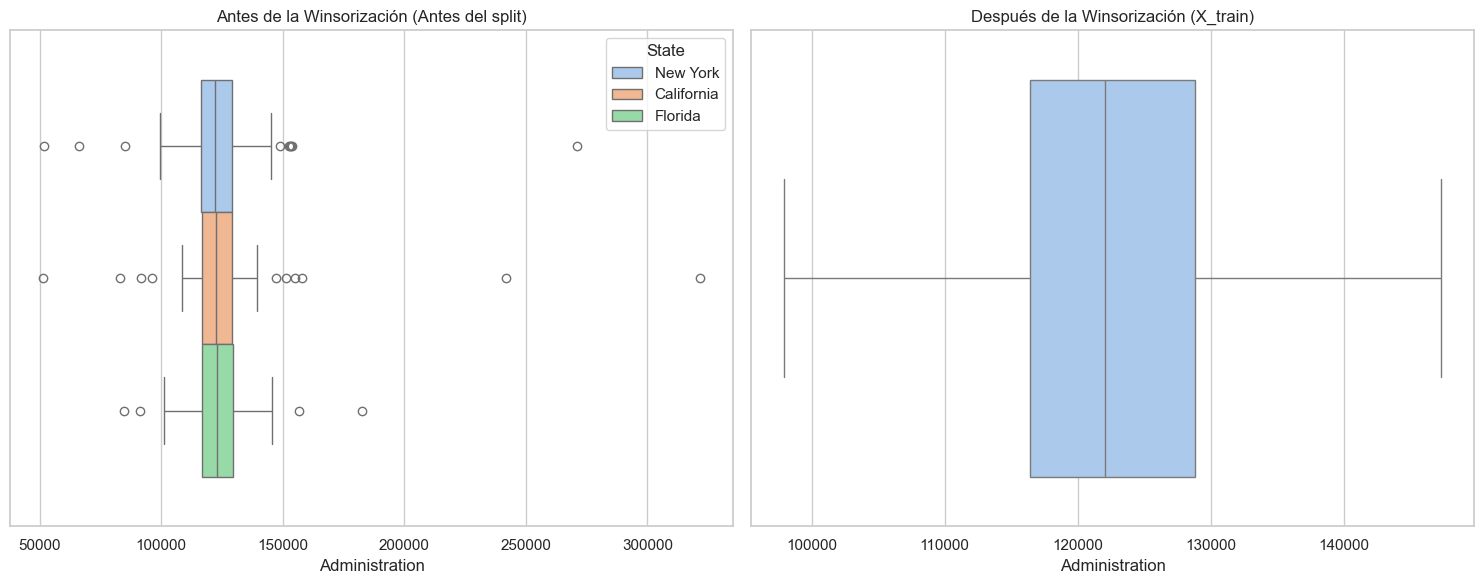

In [149]:
# Crear una figura con dos subplots, uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Datos originales
sns.boxplot(data=df, x='Administration', ax=axes[0],hue = "State")
axes[0].set_title('Antes de la Winsorización (Antes del split)')

# Gráfico 2: Datos limpios
sns.boxplot(data=X_train80, x='Administration', ax=axes[1])
axes[1].set_title('Después de la Winsorización (X_train)')

plt.tight_layout()
plt.show()

Se realiza un capeo de los outliers apartir de estadisticos en x_train para evitar fuga de datos, luego se aplica sobre x_test la transformacion con los estadisticos obtenidos previamente.

Escalamos los datos numéricos para ambos splits

In [150]:
col_scl = ['RyD_Spend','Administration', 'MarketingSpend']
esc = StandardScaler()

# primer split
X_train80[col_scl] = esc.fit_transform(X_train80[col_scl])
X_test20[col_scl] = esc.transform(X_test20[col_scl])

# segundo split
X_train70[col_scl] = esc.fit_transform(X_train70[col_scl])
X_test30[col_scl] = esc.transform(X_test30[col_scl])

## Decision tree - Companies

Para determinar la configuración óptima del Árbol de Decisión de Regresión, se empleará la técnica de Búsqueda en Grilla con Validación Cruzada (GridSearchCV)

In [151]:
dtr = DecisionTreeRegressor(random_state=42)

param_grid = {
    'criterion': ['squared_error'], # Opción principal para regresión
    'max_depth': [3, 5, 7, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

### 80-20 split

In [152]:
grid_search = GridSearchCV(estimator=dtr, param_grid=param_grid, cv=5, 
                           scoring='neg_mean_squared_error', verbose=1, n_jobs=-1) # scoring con rmse para mas interpretabilidad 

# Entrenar en los datos de entrenamiento
grid_search.fit(X_train80, y_train80)

# --- Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred = best_tree.predict(X_test20)
y_pred_train80 = best_tree.predict(X_train80)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros encontrados: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


Las métricas del conjunto de train son prácticamente perfectas, lo cual puede mostrar algún indicio de overfitting. 

In [153]:
mae_train = mean_absolute_error(y_train80, y_pred_train80)
mse_train = mean_squared_error(y_train80, y_pred_train80)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train80, y_pred_train80)

print(f"\nResultados en el conjunto de Train80:")
print(f"Error Absoluto Medio (MAE): {mae_train:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_train:.2f}")
print(f"R2: {r2_train}")



Resultados en el conjunto de Train80:
Error Absoluto Medio (MAE): 1753.34
Raíz del Error Cuadrático Medio (RMSE): 12701.17
R2: 0.9142469342478746


<Axes: xlabel='Profit'>

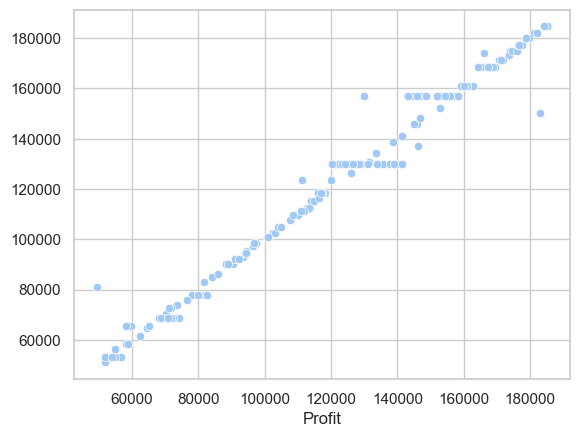

In [154]:
sns.scatterplot(x = y_test20,y = y_pred)

Las métricas obtenidas en test son incluso mejores que las obtenidas en train(casi perfectas), por lo que se intuye que el modelo ha conseguido una gran capacidad de predicción de la variable profit en base a las variables explicativas del dataset.


Resultados en el conjunto de test:
Error Absoluto Medio (MAE): 2777.45
Raíz del Error Cuadrático Medio (RMSE): 5423.89
R2: 0.9817860817360555


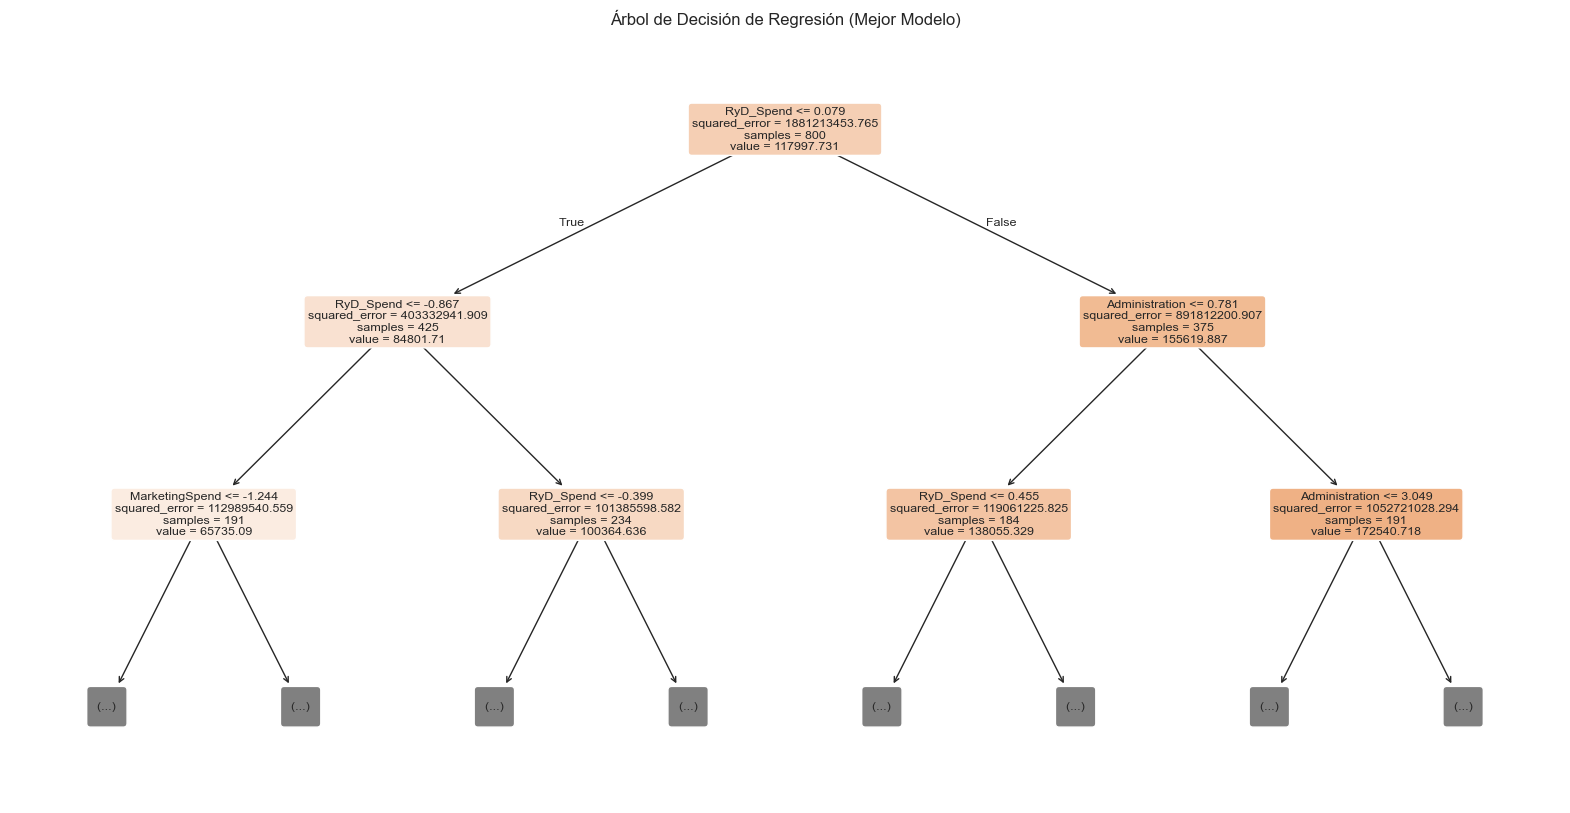

In [155]:
mae = mean_absolute_error(y_test20, y_pred)
mse = mean_squared_error(y_test20, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test20, y_pred)

print(f"\nResultados en el conjunto de test:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"R2: {r2}")

# --- Graficar el Árbol ---
plt.figure(figsize=(20, 10))
plot_tree(best_tree, 
          feature_names=X_train80.columns.tolist(), # Asegúrate que X_train sea un DataFrame
          filled=True, 
          rounded=True,
          max_depth=2) # Limitar la profundidad para que sea legible
plt.title("Árbol de Decisión de Regresión (Mejor Modelo)")
plt.show()

### 70-30 split

In [156]:
grid_search2 = GridSearchCV(estimator=dtr, param_grid=param_grid, cv=5, 
                           scoring='neg_mean_squared_error', verbose=1, n_jobs=-1) # scoring con rmse para mas interpretabilidad 

# Entrenar en los datos de entrenamiento
grid_search2.fit(X_train70, y_train70)

# --- Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search2.best_params_}")
best_tree2 = grid_search2.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred2 = best_tree.predict(X_test30)
y_pred_train70 = best_tree.predict(X_train70)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros encontrados: {'criterion': 'squared_error', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [157]:
mae_train2 = mean_absolute_error(y_train70, y_pred_train70)
mse_train2 = mean_squared_error(y_train70, y_pred_train70)
rmse_train2 = np.sqrt(mse_train2)
r2_train2 = r2_score(y_train70, y_pred_train70)

print(f"\nResultados en el conjunto de Train80:")
print(f"Error Absoluto Medio (MAE): {mae_train2:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_train2:.2f}")
print(f"R2: {r2_train2}")



Resultados en el conjunto de Train80:
Error Absoluto Medio (MAE): 4224.71
Raíz del Error Cuadrático Medio (RMSE): 12009.00
R2: 0.9201023272057903


In [158]:
mae_train2 = mean_absolute_error(y_test30, y_pred2)
mse_train2 = mean_squared_error(y_test30, y_pred2)
rmse_train2 = np.sqrt(mse_train2)
r2_train2 = r2_score(y_test30, y_pred2)

print(f"\nResultados en el conjunto de Train80:")
print(f"Error Absoluto Medio (MAE): {mae_train2:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_train2:.2f}")
print(f"R2: {r2_train2}")



Resultados en el conjunto de Train80:
Error Absoluto Medio (MAE): 4838.13
Raíz del Error Cuadrático Medio (RMSE): 14089.03
R2: 0.8959836378578663


<Axes: xlabel='Profit'>

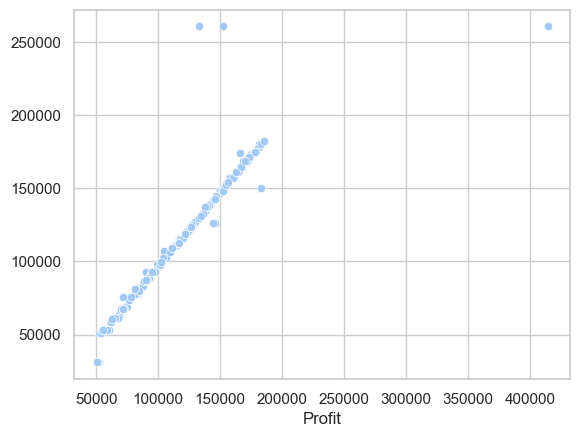

In [159]:
sns.scatterplot(x = y_test30,y = y_pred2)

Por la naturaleza aleatoria del split se observa que los valores outliers de Profit caen dentro del conjunto de test y se refleja en el gráfico anterior. Esto tambián indica que el modelo no tuvo exposición a valores atípicos de la variable de profit lo que puede reducir su capacidad de generalización.

## EDA Drugs

In [160]:
df2 = pd.read_csv('drugType.csv')

In [161]:
df2.head()

,Edad,Sexo,BP,Colesterol,Na_a_K,Droga
0,23,F,Alto,Alto,25.355,DrogaY
1,47,M,Bajo,Alto,13.093,DrogaC
2,47,M,Bajo,Alto,10.114,DrogaC
3,28,F,Normal,Alto,7.798,DrogaX
4,61,F,Bajo,Alto,18.043,DrogaY


In [162]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Edad        200 non-null    int64  
 1   Sexo        200 non-null    object 
 2   BP          200 non-null    object 
 3   Colesterol  200 non-null    object 
 4   Na_a_K      200 non-null    float64
 5   Droga       200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [163]:
df2.describe()

,Edad,Na_a_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [164]:
print(df2.isna().sum()[df2.isna().sum() > 0]) # no hay nulos

Series([], dtype: int64)


In [165]:
df2_copy = df2.copy()

In [166]:
# Convertimos a categoria la columna objetivo
df2_copy['Droga'] = df2_copy['Droga'].astype('category')
df2_copy["Droga"].value_counts()

Droga
DrogaY    91
DrogaX    54
DrogaA    23
DrogaC    16
DrogaB    16
Name: count, dtype: int64

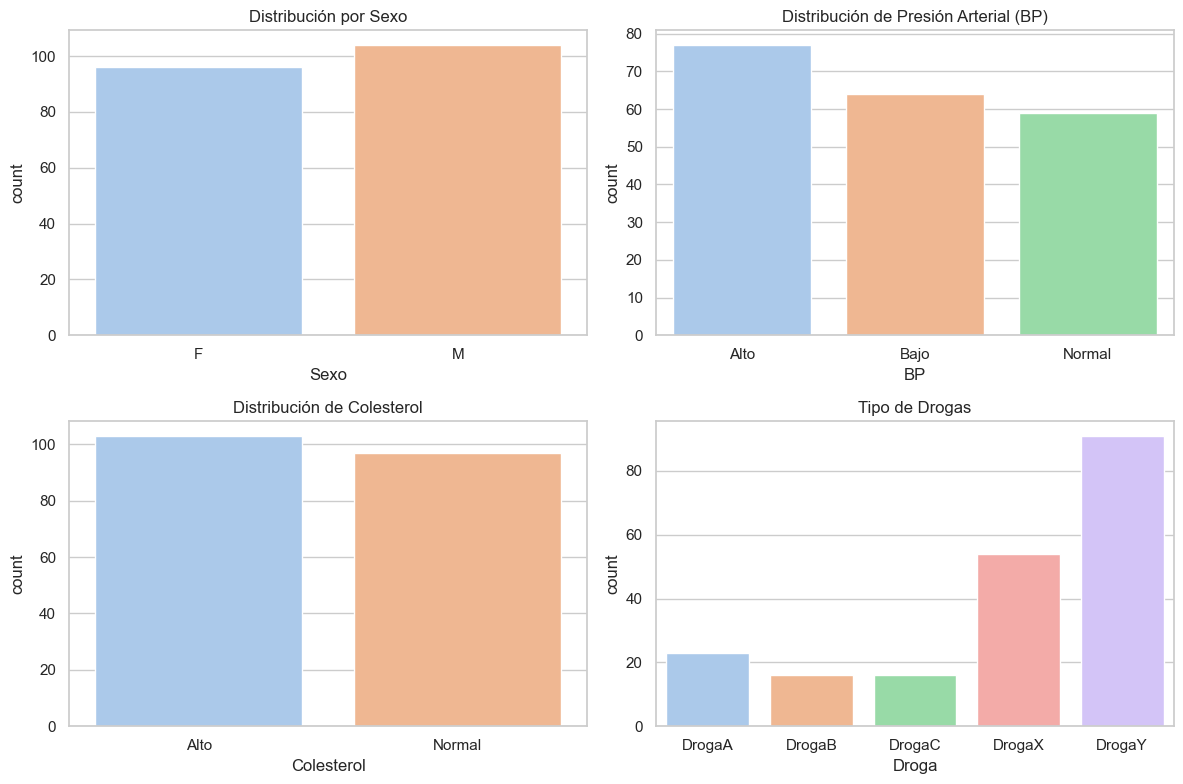

In [167]:
sns.set(style="whitegrid", palette="pastel")

# Crear figura y ejes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gráficos
sns.countplot(data=df2_copy, x='Sexo', hue='Sexo', ax=axes[0,0])
axes[0,0].set_title('Distribución por Sexo')

sns.countplot(data=df2_copy, x='BP', hue='BP', ax=axes[0,1])
axes[0,1].set_title('Distribución de Presión Arterial (BP)')

sns.countplot(data=df2_copy, x='Colesterol', hue='Colesterol', ax=axes[1,0])
axes[1,0].set_title('Distribución de Colesterol')

sns.countplot(data=df2_copy, x='Droga', hue='Droga', ax=axes[1,1])
axes[1,1].set_title('Tipo de Drogas')

# Ajustar espaciado
plt.tight_layout()
plt.show()


Se puede observar un desbalance de la cantidad de entradas disponibles para cada tipo de droga, habiendo menos de 20 entradas para el tipo B y el tipo C. 

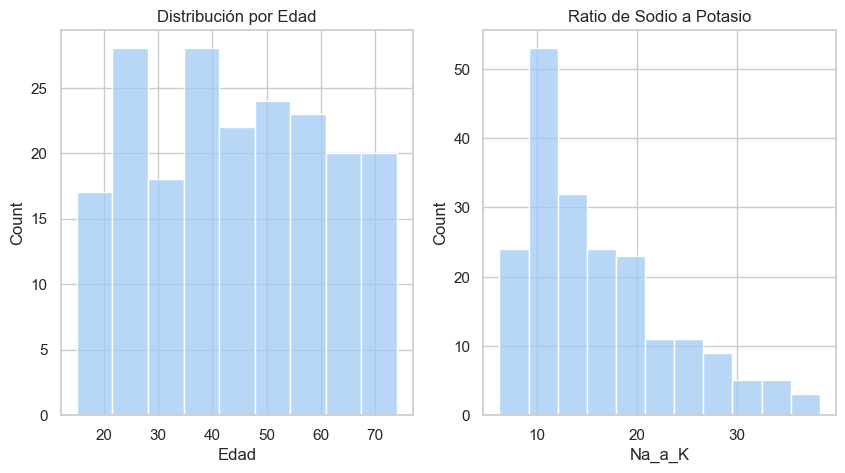

In [168]:
sns.set(style="whitegrid", palette="pastel")

# Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Gráficos
sns.histplot(data=df2_copy, x='Edad', ax=axes[0])
axes[0].set_title('Distribución por Edad')

sns.histplot(data=df2_copy, x='Na_a_K', ax=axes[1])
axes[1].set_title('Ratio de Sodio a Potasio')

# Ajustar espaciado
#plt.tight_layout()
plt.show()


Se ve ligeramente sesgado a la derecha El ratio de sodio y potacio

In [169]:
df2_copy.BP.unique()

array(['Alto', 'Bajo', 'Normal'], dtype=object)

In [170]:
# Codificamos de esta manera ya que es una varable categorica ordinal, el orden de bajo normal y alto importa
bp_map = {'Bajo': 0, 'Normal': 1, 'Alto': 2}
df2_copy['BP'] = df2_copy['BP'].map(bp_map)

In [171]:
df2_copy.Colesterol.unique()

array(['Alto', 'Normal'], dtype=object)

In [172]:
col_map = {'Normal': 0, 'Alto': 1}
df2_copy['Colesterol'] = df2_copy['Colesterol'].map(col_map)

In [173]:
df2_copy.head()

,Edad,Sexo,BP,Colesterol,Na_a_K,Droga
0,23,F,2,1,25.355,DrogaY
1,47,M,0,1,13.093,DrogaC
2,47,M,0,1,10.114,DrogaC
3,28,F,1,1,7.798,DrogaX
4,61,F,0,1,18.043,DrogaY


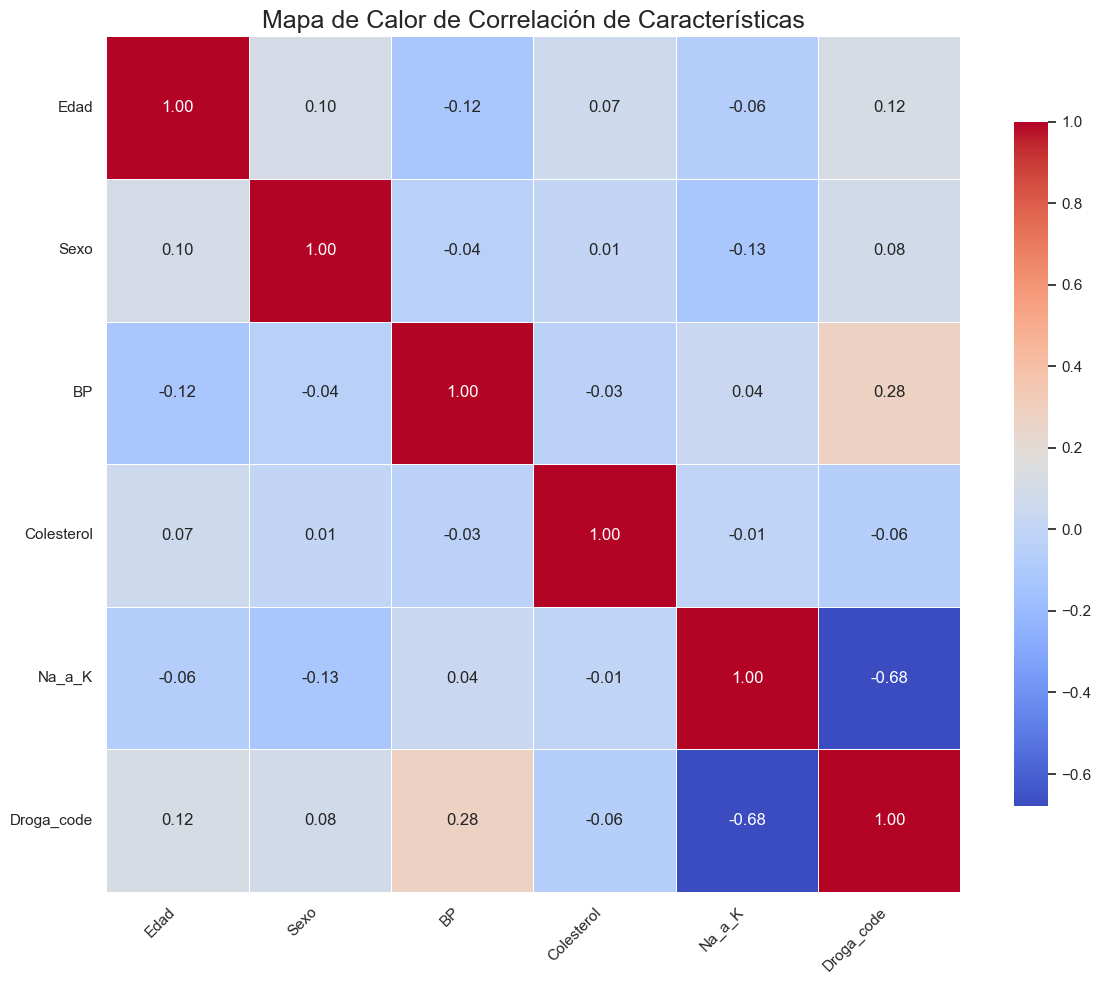

In [174]:
# Creamos copia
df_corr = df2_copy.copy()
df_corr['Droga_code'] = pd.factorize(df_corr['Droga'])[0]
df_corr['Sexo'] = df_corr['Sexo'].apply(lambda x: 1 if x == 'M' else 0)
corr_matrix = df_corr[['Edad', 'Sexo', 'BP', 'Colesterol', 'Na_a_K', 'Droga_code']].corr()


plt.figure(figsize=(12, 10))  # Tamaño generoso para que se vea bien


sns.heatmap(
    corr_matrix,       
    annot=True,           
    fmt=".2f",            
    cmap='coolwarm',      
    linewidths=.5,        
    cbar_kws={"shrink": .8} 
)

plt.title('Mapa de Calor de Correlación de Características', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)


plt.tight_layout() # Ajusta el gráfico para que todo encaje bien
plt.show()

para la columna Sexo se plantea el uso de OneHotEncoding 

In [175]:
enc = OneHotEncoder(sparse_output=False) 

fit = enc.fit_transform(df2_copy[['Sexo']])

df_enc = pd.DataFrame(fit, columns=enc.get_feature_names_out(['Sexo']), index=df2.index)

# concatenamos los dataframe y dropeamos la columna que codificamos
df2_copy = pd.concat([df2_copy, df_enc], axis=1)
df2_copy.drop('Sexo', axis=1, inplace=True)

In [176]:
df2_copy.head()

,Edad,BP,Colesterol,Na_a_K,Droga,Sexo_F,Sexo_M
0,23,2,1,25.355,DrogaY,1.0,0.0
1,47,0,1,13.093,DrogaC,0.0,1.0
2,47,0,1,10.114,DrogaC,0.0,1.0
3,28,1,1,7.798,DrogaX,1.0,0.0
4,61,0,1,18.043,DrogaY,1.0,0.0


### SPLIT Drug

In [177]:
X = df2_copy.drop('Droga', axis=1)
y = df2_copy['Droga']

# --- Escenario 1: División 80/20 ---
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# --- Escenario 2: División 70/30 ---
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [178]:
X_train_80.head()

,Edad,BP,Colesterol,Na_a_K,Sexo_F,Sexo_M
196,16,0,1,12.006,0.0,1.0
134,42,2,1,21.036,1.0,0.0
24,33,0,1,33.486,1.0,0.0
2,47,0,1,10.114,0.0,1.0
97,56,2,1,25.395,1.0,0.0


In [179]:
X_test_20.head()

,Edad,BP,Colesterol,Na_a_K,Sexo_F,Sexo_M
84,47,0,1,10.067,1.0,0.0
32,49,0,0,11.014,0.0,1.0
110,50,2,1,7.490,0.0,1.0
129,32,1,1,7.477,1.0,0.0
57,40,2,1,27.826,0.0,1.0


In [180]:
X_train_80.columns

Index(['Edad', 'BP', 'Colesterol', 'Na_a_K', 'Sexo_F', 'Sexo_M'], dtype='object')

In [181]:
columnas = ['Edad','Na_a_K','Colesterol','BP']
esc = StandardScaler()

# escalamos los split de 70-30 y 80-20
X_train_80[columnas] = esc.fit_transform(X_train_80[columnas])
X_test_20[columnas] = esc.transform(X_test_20[columnas])

X_train_70[columnas] = esc.fit_transform(X_train_70[columnas])
X_test_30[columnas] = esc.transform(X_test_30[columnas])

ESTA BIEN EL LABEL ENCODER PARRA LA Y O NO HACE FALTA

In [182]:
# le = LabelEncoder()
# y_train_encoded = le.fit_transform(y_train_70)
# y_test_encoded = le.transform(y_test_30)

In [183]:
# nombres_drogas = le.classes_

### Modelo 70-30

In [184]:
X_train_70.head()

,Edad,BP,Colesterol,Na_a_K,Sexo_F,Sexo_M
158,0.805604,-1.279672,0.985815,-0.810058,1.0,0.0
46,-0.514918,1.141329,0.985815,-0.433269,1.0,0.0
130,1.465865,-0.069171,0.985815,0.619803,1.0,0.0
31,1.705960,1.141329,0.985815,-0.934895,0.0,1.0
85,0.805604,1.141329,0.985815,-0.313130,0.0,1.0


In [185]:
X_train_70.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 158 to 175
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Edad        140 non-null    float64
 1   BP          140 non-null    float64
 2   Colesterol  140 non-null    float64
 3   Na_a_K      140 non-null    float64
 4   Sexo_F      140 non-null    float64
 5   Sexo_M      140 non-null    float64
dtypes: float64(6)
memory usage: 7.7 KB


In [186]:
dtr_70 = DecisionTreeClassifier(random_state=42)

param_grid_70 = {
    'criterion': ['gini', 'entropy'], # Opción principal para regresión
    'max_depth': [3, 5, 7, 10,12, None],
    'min_samples_split': [3, 5, 7, 9, 11, 13],
    'min_samples_leaf': [1, 2, 4,8,12]
}

In [187]:
grid_search = GridSearchCV(estimator=dtr_70, param_grid=param_grid_70, cv=5, 
                           scoring='f1_weighted', verbose=1, n_jobs=-1) 

# Entrenar en los datos de entrenamiento
grid_search.fit(X_train_70, y_train_70)

# --- Paso 3: Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred_30_test = best_tree.predict(X_test_30)
y_pred_70_train = best_tree.predict(X_train_70)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3}


In [188]:
# Generar matrices de confusión.
confusion_70_train = confusion_matrix(y_train_70,y_pred_70_train)
confusion_30_test = confusion_matrix(y_test_30,y_pred_30_test)

Se observan métricas perfectas para train, lo cual es un gran indicio de posible overfitting.

In [189]:
# Métricas para Train
print(classification_report(y_train_70,y_pred_70_train))

              precision    recall  f1-score   support

      DrogaA       1.00      1.00      1.00        16
      DrogaB       1.00      1.00      1.00        11
      DrogaC       1.00      1.00      1.00        11
      DrogaX       1.00      1.00      1.00        38
      DrogaY       1.00      1.00      1.00        64

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



In [190]:
nombres_drogas = y_train_70.unique()

Como se ve debajo, la matriz obtenida es la perfecta, con valores solo en la diagonal.

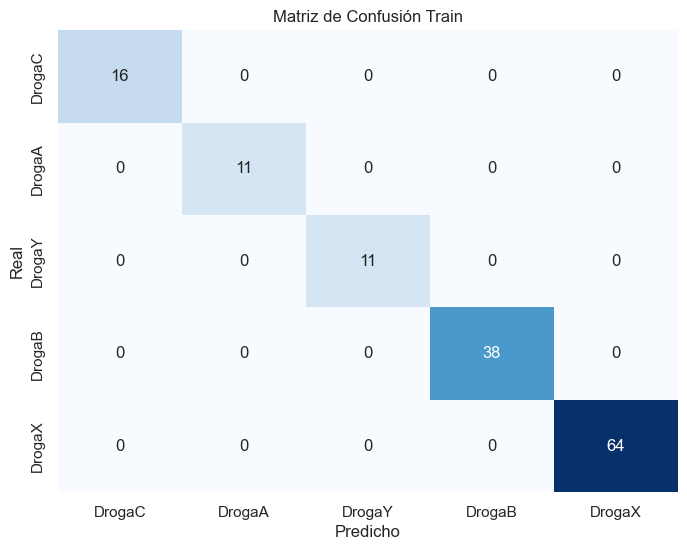

In [191]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_70_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

Las métricas siguen siendo extremadamente positivas en test, por lo que se concluye que se ha llegado a obtener un modelo muy preciso a la hora de predecir las diferentes drogas en base a datos del paciente.

In [192]:
# Métricas para test
print(classification_report(y_test_30,y_pred_30_test,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaC       0.88      1.00      0.93         7
      DrogaA       1.00      0.80      0.89         5
      DrogaY       1.00      1.00      1.00         5
      DrogaB       1.00      1.00      1.00        16
      DrogaX       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



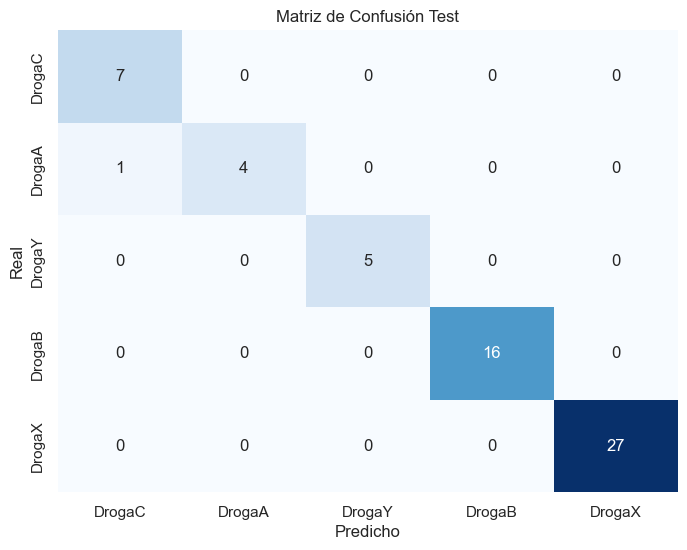

In [193]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_30_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas  
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

Solamente se poredice de manera errónea un solo valor.

Se visualiza a continuación el árbol obtenido durante el entrenamiento.

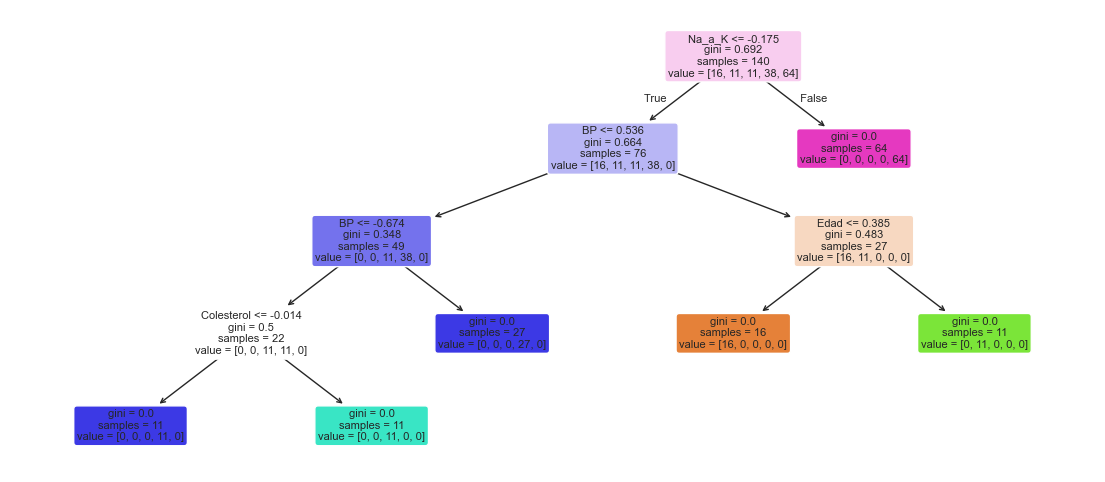

In [194]:
plt.figure(figsize=(14,6))
plot_tree(grid_search.best_estimator_, feature_names=X_train_70.columns, fontsize=8, filled=True,
               rounded=True)
plt.show()

### Modelo 80-20

In [195]:
X_train_80.head()

,Edad,BP,Colesterol,Na_a_K,Sexo_F,Sexo_M
196,-1.697812,-1.271036,0.975305,-0.550278,0.0,1.0
134,-0.161397,1.135659,0.975305,0.741886,1.0,0.0
24,-0.693233,-1.271036,0.975305,2.523441,1.0,0.0
2,0.134067,-1.271036,0.975305,-0.821017,0.0,1.0
97,0.665903,1.135659,0.975305,1.365645,1.0,0.0


In [196]:
X_train_80.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160 entries, 196 to 4
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Edad        160 non-null    float64
 1   BP          160 non-null    float64
 2   Colesterol  160 non-null    float64
 3   Na_a_K      160 non-null    float64
 4   Sexo_F      160 non-null    float64
 5   Sexo_M      160 non-null    float64
dtypes: float64(6)
memory usage: 8.8 KB


In [197]:
dtr_80 = DecisionTreeClassifier(random_state=42)

param_grid_80 = {
    'criterion': ['gini', 'entropy'], # Opción principal para regresión
    'max_depth': [3, 5, 7,10,12, None],
    'min_samples_split': [3, 5, 7, 9, 11, 13],
    'min_samples_leaf': [1, 2, 4,8,12]
}

In [198]:
# y_train_encoded2 = .fit_transform(y_train_80)
# y_test_encoded2 = le.transform(y_test_20)

In [199]:
grid_search2 = GridSearchCV(estimator=dtr_80, param_grid=param_grid_80, cv=5, 
                           scoring='f1_weighted', verbose=1, n_jobs=-1) 

# Entrenar en los datos de entrenamiento
grid_search2.fit(X_train_80, y_train_80)

# --- Paso 3: Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search2.best_params_}")
best_tree = grid_search2.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred_20_test = best_tree.predict(X_test_20)
y_pred_80_train = best_tree.predict(X_train_80)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3}


In [200]:
# Generar matrices de confusión.
confusion_80_train = confusion_matrix(y_train_80,y_pred_80_train)
confusion_20_test = confusion_matrix(y_test_20,y_pred_20_test)

Nuevamente las métricas son perfectas para train, lo cual puede indicar overfitting.

In [201]:
# Métricas para Train
print(classification_report(y_train_80,y_pred_80_train,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaC       1.00      1.00      1.00        18
      DrogaA       1.00      1.00      1.00        13
      DrogaY       1.00      1.00      1.00        13
      DrogaB       1.00      1.00      1.00        43
      DrogaX       1.00      1.00      1.00        73

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



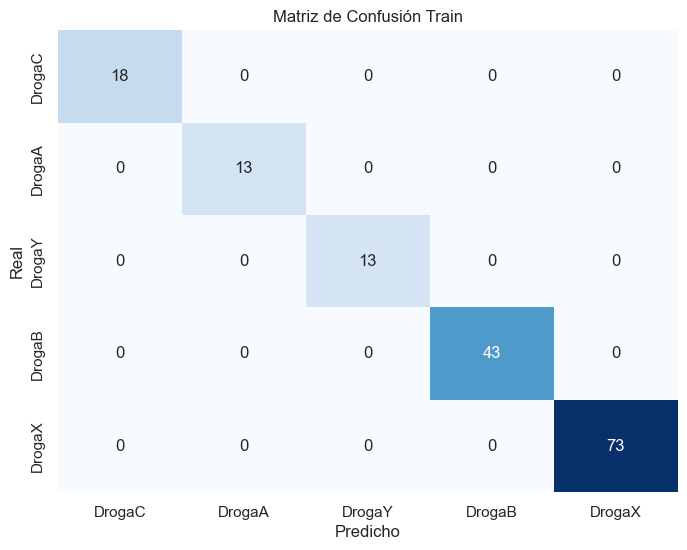

In [202]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_80_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

Igualmente que en el otro split, los resultados siguen siendo positivos en test, por lo que se concluye que se obtuvo un fitting positivo. 

In [203]:
# Métricas para test
print(classification_report(y_test_20,y_pred_20_test,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaC       0.83      1.00      0.91         5
      DrogaA       1.00      0.67      0.80         3
      DrogaY       1.00      1.00      1.00         3
      DrogaB       1.00      1.00      1.00        11
      DrogaX       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40



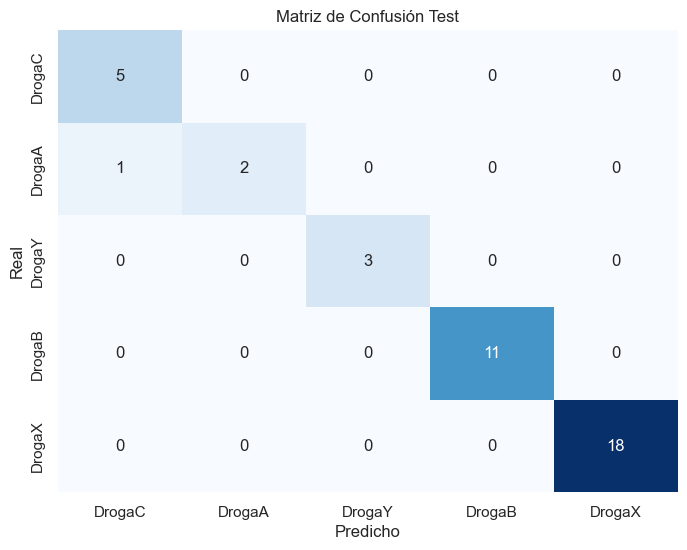

In [204]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_20_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas   
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

Solamente predice mal un valor, igual que en el split anterior.

# Bayes Ingenuo

In [205]:
df3 = df2.copy()

In [206]:
# Observación de estadísticas de variables numéricas
df3.describe()

,Edad,Na_a_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


Discretización de variables para Naive Bayes, basadas en lo visto anteriormente en describe, usando los cuartiles como referencia. 

In [207]:
df3['Na_a_K_Cat'] = pd.qcut(df3['Na_a_K'], q=4, labels=False)
df3['Edad_Cat'] = pd.qcut(df3['Edad'], q=4, labels = False)
df3 = df3.drop(columns=["Edad","Na_a_K"])

In [208]:
df3['Sexo'] = df3['Sexo'].apply(lambda x: 1 if x == 'M' else 0)
bp_map = {'Bajo': 0, 'Normal': 1, 'Alto': 2}
df3['BP'] = df3['BP'].map(bp_map)
col_map = {'Normal': 0, 'Alto': 1}
df3['Colesterol'] = df3['Colesterol'].map(col_map)

In [209]:
df3.head()

,Sexo,BP,Colesterol,Droga,Na_a_K_Cat,Edad_Cat
0,0,2,1,DrogaY,3,0
1,1,0,1,DrogaC,1,2
2,1,0,1,DrogaC,0,2
3,0,1,1,DrogaX,0,0
4,0,0,1,DrogaY,2,3


In [210]:
X2 = df3.drop('Droga', axis=1)
y2 = df3['Droga']

# Primer split para naives
X_train80n, X_test20n, y_train80n, y_test20n = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Segundo split para naives
X_train70n, X_test30n, y_train70n, y_test30n = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2)

### 80-20 split

In [211]:
# Se utilizó MultinomialNB para variables discretas 
clf_MNB = MultinomialNB()
clf_MNB.fit(X_train80n, y_train80n)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [212]:
pred_MNB_train= clf_MNB.predict(X_train80n)
pred_MNB_test= clf_MNB.predict(X_test20n)

In [213]:
print(classification_report(y_train80n,pred_MNB_train,target_names = nombres_drogas,zero_division=0));

              precision    recall  f1-score   support

      DrogaC       1.00      0.17      0.29        18
      DrogaA       0.00      0.00      0.00        13
      DrogaY       0.00      0.00      0.00        13
      DrogaB       0.48      0.53      0.51        43
      DrogaX       0.67      1.00      0.80        73

    accuracy                           0.62       160
   macro avg       0.43      0.34      0.32       160
weighted avg       0.55      0.62      0.53       160



In [214]:
print(classification_report(y_test20n,pred_MNB_test,target_names = nombres_drogas,zero_division=0));

              precision    recall  f1-score   support

      DrogaC       0.00      0.00      0.00         5
      DrogaA       0.00      0.00      0.00         3
      DrogaY       0.00      0.00      0.00         3
      DrogaB       0.42      0.45      0.43        11
      DrogaX       0.61      0.94      0.74        18

    accuracy                           0.55        40
   macro avg       0.20      0.28      0.23        40
weighted avg       0.39      0.55      0.45        40



Se ven metricas con valores 0.0, lo que puede indicar que debido a la naturaleza del split algunas combinacion de atributos no se encuentran dentro de train, por lo que el modelo no tiene informacion suficiente para calcular la probabilidad condicional.

### 70-30 split

In [215]:
# Se utilizó MultinomialNB para variables discretas 
clf_MNB2 = MultinomialNB()
clf_MNB2.fit(X_train70n, y_train70n)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [216]:
pred_MNB_train2 = clf_MNB2.predict(X_train70n)
pred_MNB_test2 = clf_MNB2.predict(X_test30n)

In [217]:
print(classification_report(y_train70n,pred_MNB_train2,target_names = nombres_drogas,zero_division=0));

              precision    recall  f1-score   support

      DrogaC       1.00      0.12      0.22        16
      DrogaA       0.00      0.00      0.00        11
      DrogaY       0.00      0.00      0.00        11
      DrogaB       0.48      0.53      0.50        38
      DrogaX       0.67      1.00      0.80        64

    accuracy                           0.61       140
   macro avg       0.43      0.33      0.30       140
weighted avg       0.55      0.61      0.53       140



In [218]:
print(classification_report(y_test30n,pred_MNB_test2,target_names = nombres_drogas,zero_division=0));

              precision    recall  f1-score   support

      DrogaC       1.00      0.14      0.25         7
      DrogaA       0.00      0.00      0.00         5
      DrogaY       0.00      0.00      0.00         5
      DrogaB       0.42      0.50      0.46        16
      DrogaX       0.65      0.96      0.78        27

    accuracy                           0.58        60
   macro avg       0.41      0.32      0.30        60
weighted avg       0.52      0.58      0.50        60



Nuevamente se observa el mismo comportamiento que en el split de 80-20.

# KNN

In [219]:
df2_copy

,Edad,BP,Colesterol,Na_a_K,Droga,Sexo_F,Sexo_M
0,23,2,1,25.355,DrogaY,1.0,0.0
1,47,0,1,13.093,DrogaC,0.0,1.0
2,47,0,1,10.114,DrogaC,0.0,1.0
3,28,1,1,7.798,DrogaX,1.0,0.0
4,61,0,1,18.043,DrogaY,1.0,0.0
...,...,...,...,...,...,...,...
195,56,0,1,11.567,DrogaC,1.0,0.0
196,16,0,1,12.006,DrogaC,0.0,1.0
197,52,1,1,9.894,DrogaX,0.0,1.0
198,23,1,0,14.020,DrogaX,0.0,1.0


In [232]:
X3 = df2_copy.drop('Droga', axis=1)
y3 = df2_copy['Droga']

# Primer split knn
X_train80k, X_test20k, y_train80k, y_test20k = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3)
# Segundo split knn
X_train70k, X_test30k, y_train70k, y_test30k = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y3)

In [233]:
scaler = StandardScaler()

# Escalado primer split
X_train80k_scaled = scaler.fit_transform(X_train80k)
X_test20k_scaled = scaler.transform(X_test20k)

# Escalado segundo split
X_train70k_scaled = scaler.fit_transform(X_train70k)
X_test30k_scaled = scaler.transform(X_test30k)

In [234]:
knn = KNeighborsClassifier()

In [237]:
# Definir los parámetros a ajustar
parametros_grid = {'n_neighbors': range(3, 30),
                   'p':[1,2],
                   }

### 80-20 split

In [238]:
# Inicializar el objeto GridSearchCV
grid_search = GridSearchCV(estimator = knn,
                           param_grid = parametros_grid,
                           cv=5,
                           scoring='f1_weighted') # se selecciona f1_weighted ya que considera metricas de recall como de precision.

In [239]:
grid_search.fit(X_train80k_scaled, y_train80k)
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

Mejores parámetros encontrados: {'n_neighbors': 5, 'p': 1}


In [246]:
best_knn80 = grid_search.best_estimator_

In [247]:
y_pred_train80k = best_knn80.predict(X_train80k_scaled)
y_pred_test20k = best_knn80.predict(X_test20k_scaled)

In [248]:
confusion_k_train80 = confusion_matrix(y_train80k,y_pred_train80k)
confusion_k_test80 = confusion_matrix(y_test20k,y_pred_test20k)

In [249]:
print(classification_report(
    y_train80k, 
    y_pred_train80k, 
    target_names=nombres_drogas
))

              precision    recall  f1-score   support

      DrogaC       0.88      0.83      0.86        18
      DrogaA       0.86      0.92      0.89        13
      DrogaY       0.87      1.00      0.93        13
      DrogaB       0.88      1.00      0.93        43
      DrogaX       0.97      0.86      0.91        73

    accuracy                           0.91       160
   macro avg       0.89      0.92      0.90       160
weighted avg       0.92      0.91      0.91       160



Las métricas en train son positivas con todas las clases, no se presenta algún sesgo particular por el desbalance de las clases.

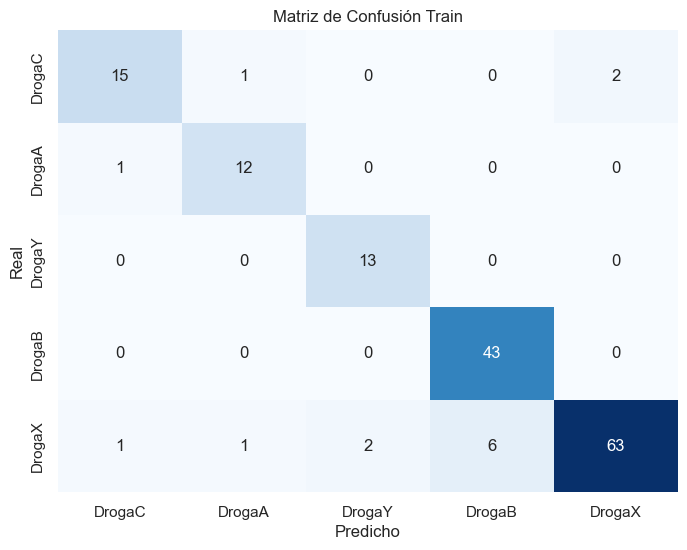

In [250]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_train80,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

In [251]:
print(classification_report(
    y_test20k, 
    y_pred_test20k, 
    target_names=nombres_drogas
))

              precision    recall  f1-score   support

      DrogaC       0.50      0.80      0.62         5
      DrogaA       0.50      0.67      0.57         3
      DrogaY       1.00      1.00      1.00         3
      DrogaB       0.91      0.91      0.91        11
      DrogaX       0.93      0.72      0.81        18

    accuracy                           0.80        40
   macro avg       0.77      0.82      0.78        40
weighted avg       0.84      0.80      0.81        40



Las métricas de train muestran valores de f-1 score mas bajos para dos de las categorías que cuentan con un menor número de entradas(C y A).

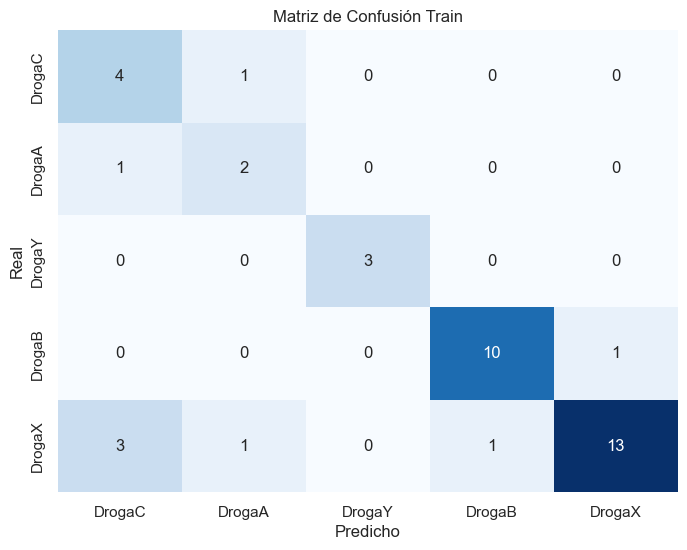

In [252]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_test80,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

### 70-30 split

In [253]:
# Inicializar el objeto GridSearchCV
grid_search2 = GridSearchCV(estimator = knn,
                           param_grid = parametros_grid,
                           cv=5,
                           scoring='f1_weighted') # se selecciona f1_weighted ya que considera metricas de recall como de precision.

In [254]:
grid_search2.fit(X_train70k_scaled, y_train70k)
print(f"Mejores parámetros encontrados: {grid_search2.best_params_}")

Mejores parámetros encontrados: {'n_neighbors': 3, 'p': 1}


In [255]:
best_knn70 = grid_search2.best_estimator_

In [256]:
y_pred_train70k = best_knn70.predict(X_train70k_scaled)
y_pred_test30k = best_knn70.predict(X_test30k_scaled)

In [257]:
confusion_k_train70 = confusion_matrix(y_train70k,y_pred_train70k)
confusion_k_test70 = confusion_matrix(y_test30k,y_pred_test30k)

In [258]:
print(classification_report(
    y_train70k, 
    y_pred_train70k, 
    target_names=nombres_drogas
))

              precision    recall  f1-score   support

      DrogaC       0.94      1.00      0.97        16
      DrogaA       0.92      1.00      0.96        11
      DrogaY       0.85      1.00      0.92        11
      DrogaB       0.93      1.00      0.96        38
      DrogaX       1.00      0.89      0.94        64

    accuracy                           0.95       140
   macro avg       0.93      0.98      0.95       140
weighted avg       0.95      0.95      0.95       140



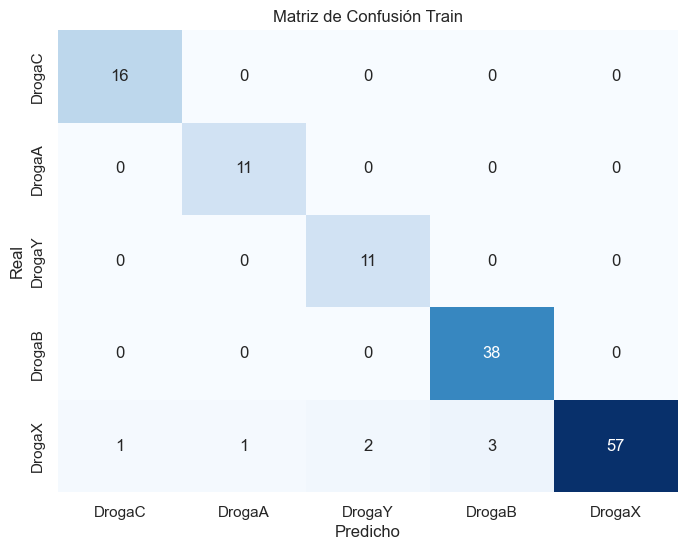

In [259]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_train70,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

In [260]:
print(classification_report(
    y_test30k, 
    y_pred_test30k, 
    target_names=nombres_drogas
))

              precision    recall  f1-score   support

      DrogaC       0.57      0.57      0.57         7
      DrogaA       0.57      0.80      0.67         5
      DrogaY       0.62      1.00      0.77         5
      DrogaB       0.88      0.94      0.91        16
      DrogaX       0.95      0.74      0.83        27

    accuracy                           0.80        60
   macro avg       0.72      0.81      0.75        60
weighted avg       0.83      0.80      0.80        60



Los resultados obtenidos con este split son muy similares a los obtenidos anteriormente. Los resultados en train son casi perfectos y luego en test las métricas de categorías con menor cantidad de entradas empeoran, lo que es de esperarse. 

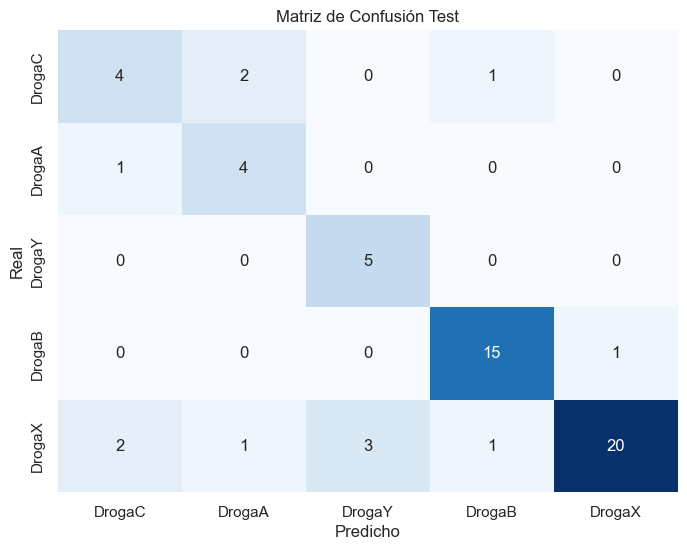

In [262]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_test70,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

# Conclusión 

Árboles: Los resultados obtenidos fueron positivos para el caso de la regresión, obteniendo valores de R2 superiores 